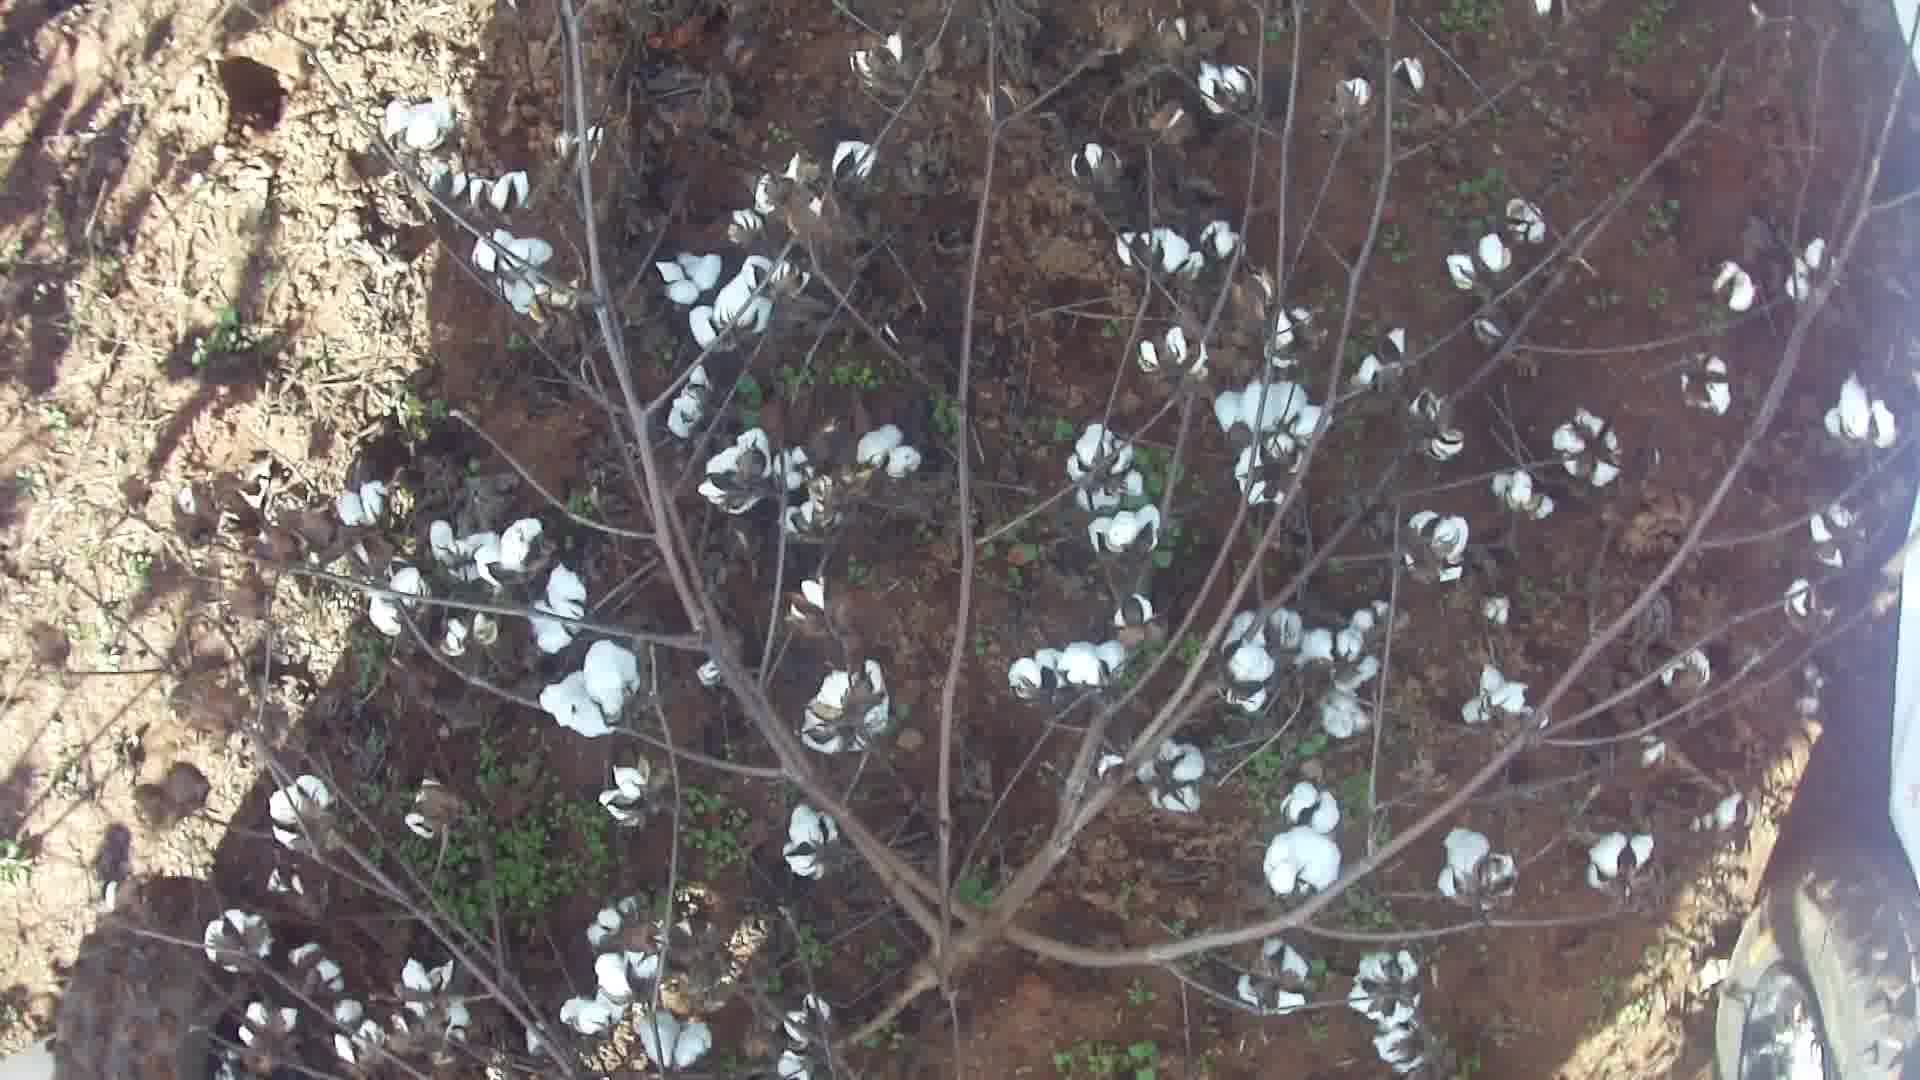

In [1]:
from PIL import Image

# Load a test image.
test_image = Image.open("test_images/boll_example.jpg").convert("RGB")
display(test_image)

In [2]:
import json
import numpy as np

data = json.dumps({"signature_name": "serving_default", "instances": np.array(test_image)[None, :, :, :].tolist()})
print('Data: {} ... {}'.format(data[:50], data[len(data)-52:]))

Data: {"signature_name": "serving_default", "instances": ... 135, 146, 166], [135, 146, 166], [135, 146, 166]]]]}


In [3]:
import requests

headers = {"content-type": "application/json"}
json_response = requests.post('http://10.138.147.180:8501/v1/models/small_boll_detector:predict', data=data, headers=headers)
predictions = json.loads(json_response.text)["predictions"]

In [4]:
predictions[0].keys()

dict_keys(['input.row_lengths_9', 'input.to_tensor_8', 'input.to_tensor_9'])

In [5]:
predictions[0]["input.to_tensor_8"]


[
    [0.67922318, 0.798052847, 0.0530170798, 0.0652436, 0.835821331],
    [0.843010545, 0.794711173, 0.0444840789, 0.0575354099, 0.793682814],
    [0.352361321, 0.963422537, 0.0444009602, 0.0518355966, 0.787532],
    [0.463208854, 0.414891094, 0.0422062278, 0.0503062606, 0.757080674],
    [0.267341554, 0.231539547, 0.0479019582, 0.0440114588, 0.752612472],
    [0.682082355, 0.744608521, 0.0378937721, 0.0465275645, 0.748614],
    [0.423181832, 0.764715791, 0.0338997543, 0.0412659049, 0.736789167],
    [0.220195338, 0.110488452, 0.0459593832, 0.047839, 0.735571325],
    [0.769651651, 0.801313162, 0.0500258803, 0.0707481503, 0.727866173],
    [0.555637538, 0.619188368, 0.0678060055, 0.0573887825, 0.725975871],
    [0.609980106, 0.321766317, 0.0447116494, 0.0449686348, 0.712638736],
    [0.660577834, 0.376495719, 0.0651091337, 0.0589144826, 0.712424695],
    [0.793768764, 0.458376348, 0.0423408151, 0.0492699146, 0.700700462],
    [0.587279201, 0.489885509, 0.0469520688, 0.0465463102, 0.6

In [22]:
predictions[0]["input.row_lengths_8"]

15

In [7]:
# Create some random bounding boxes to test tracking.
detection_bounding_boxes = np.random.random((5, 4)).tolist()
tracklet_bounding_boxes = np.random.random((4, 4)).tolist()

appearance = np.array(predictions[0]["input.to_tensor_9"])
detection_appearance = appearance[:5].tolist()
tracklet_appearance = appearance[:4].tolist()

In [8]:
import json
import numpy as np

data = json.dumps({"signature_name": "serving_default", "inputs": {
    "detection_appearance_flat": [detection_appearance],
    "detection_appearance_row_lengths": [[5]],
    "tracklet_appearance_flat": [tracklet_appearance],
    "tracklet_appearance_row_lengths": [[4]],
    "detection_geometry_flat": [detection_bounding_boxes],
    "detection_geometry_row_lengths": [[5]],
    "tracklet_geometry_flat": [tracklet_bounding_boxes],
    "tracklet_geometry_row_lengths": [[4]],
}})
print('Data: {} ... {}'.format(data[:50], data[len(data)-52:]))

Data: {"signature_name": "serving_default", "inputs": {" ... 2919353]]], "tracklet_geometry_row_lengths": [[4]]}}


In [9]:
import requests

headers = {"content-type": "application/json"}
json_response = requests.post('http://10.138.147.180:8501/v1/models/boll_tracker:predict', data=data, headers=headers)
predictions = json.loads(json_response.text)["outputs"]

In [10]:
predictions


{
    'input.to_tensor_5': [
        [
            1.0535065e-11,
            0.139984965,
            0.837287247,
            3.12278971e-05,
            0.00091751857,
            0.0052277972,
            0.00234020385,
            0.304279536,
            0.0925791115,
            0.279421836,
            0.315196276,
            0.000578039268,
            0.387911111,
            0.138386101,
            0.0348040648,
            0.127080813,
            0.310064524,
            0.000262891699,
            0.0396493189,
            0.321933478,
            0.00629855692,
            0.505845,
            0.120191447,
            0.00138225243,
            0.570099354,
            0.0954159424,
            0.0290309358,
            0.087621063,
            0.253630221,
            3.99254918
        ]
    ],
    'tf.cast_5': [30]
}

In [39]:
import grpc

# Create a channel that will be connected to the gRPC port of the container
channel = grpc.insecure_channel("localhost:8500")

In [40]:
from tensorflow_serving.apis import predict_pb2, prediction_service_pb2_grpc

# Create a stub made for prediction
# This stub will be used to send the gRPCrequest to the TF Server
stub = prediction_service_pb2_grpc.PredictionServiceStub(channel)

In [47]:
import tensorflow as tf

def predict_grpc_detect(data, input_name, stub):
    # Create a gRPC request made for prediction
    request = predict_pb2.PredictRequest()

    # Set the name of the model, for this use case it is "model"
    request.model_spec.name = "flower_detector"

    # Set which signature is used to format the gRPC query
    # here the default one "serving_default"
    request.model_spec.signature_name = "serving_default"

    # Set the input as the data
    # tf.make_tensor_proto turns a TensorFlow tensor into a Protobuf tensor
    request.inputs[input_name].CopyFrom(tf.make_tensor_proto(data))

    # Send the gRPC request to the TF Server
    result = stub.Predict(request)
    return result

grpc_outputs = predict_grpc_detect(np.array(test_image)[None, :, :, :].astype(np.float32), "detections_frame", stub)
detections = tf.make_ndarray(grpc_outputs.outputs["input.to_tensor_1"])

In [48]:
detections


array([[[4.3523341e-01, 3.6286506e-01, 3.5739772e-02, 6.7149527e-02,
         8.7855887e-01],
        [8.6039007e-01, 2.1716973e-01, 1.5395865e-02, 2.7570108e-02,
         9.6195955e-03],
        [5.6168985e-01, 1.3160715e-01, 1.0593033e-02, 1.4890853e-02,
         1.3857115e-03],
        [3.9316228e-01, 8.8315113e-03, 2.8578378e-02, 1.6925752e-02,
         1.7083272e-04],
        [6.8824685e-01, 4.1958889e-01, 1.4346505e-02, 3.0333800e-02,
         1.3761867e-04],
        [5.0352657e-01, 3.3933353e-01, 2.7951656e-02, 4.3731831e-02,
         1.2852483e-04],
        [7.2935516e-01, 4.5541534e-03, 2.5332579e-02, 8.6328089e-03,
         1.1393721e-04],
        [4.5533195e-01, 1.5467276e-01, 1.1960571e-02, 2.4685817e-02,
         6.6939319e-05],
        [4.6461341e-01, 4.7446219e-03, 2.8259724e-02, 8.8935429e-03,
         5.3370521e-05],
        [6.3706315e-01, 5.3144097e-03, 1.0606639e-02, 9.7683948e-03,
         4.6240584e-05],
        [3.5218272e-01, 7.2879861e-03, 2.6141074e-02, 1.425

In [49]:
import tensorflow as tf

def predict_grpc_track(input_dict, stub):
    # Create a gRPC request made for prediction
    request = predict_pb2.PredictRequest()

    # Set the name of the model, for this use case it is "model"
    request.model_spec.name = "flower_tracker"

    # Set which signature is used to format the gRPC query
    # here the default one "serving_default"
    request.model_spec.signature_name = "serving_default"

    # Set the input as the data
    for input_name, input_data in input_dict.items():
        # tf.make_tensor_proto turns a TensorFlow tensor into a Protobuf tensor
        request.inputs[input_name].CopyFrom(tf.make_tensor_proto(input_data))

    # Send the gRPC request to the TF Server
    result = stub.Predict(request)
    return result

input_dict = {
    "detection_appearance_flat": [detection_appearance],
    "detection_appearance_row_lengths": [[5]],
    "tracklet_appearance_flat": [tracklet_appearance],
    "tracklet_appearance_row_lengths": [[4]],
    "detection_geometry_flat": [detection_bounding_boxes],
    "detection_geometry_row_lengths": [[5]],
    "tracklet_geometry_flat": [tracklet_bounding_boxes],
    "tracklet_geometry_row_lengths": [[4]]
}

grpc_outputs = predict_grpc_track(input_dict, stub)
sinkhorn = tf.make_ndarray(grpc_outputs.outputs["input.to_tensor"])

In [50]:
sinkhorn


array([[6.0940161e-04, 2.4506625e-02, 2.7820921e-01, 2.1388032e-03,
        4.2912342e-02, 6.5246880e-01, 1.6338189e-09, 7.7520239e-01,
        1.8512041e-03, 1.0393086e-03, 4.4265784e-02, 1.8795748e-01,
        2.6366156e-01, 7.7144071e-03, 7.1101397e-01, 8.0925607e-16,
        1.9585231e-07, 1.1401221e-02, 2.9961126e-07, 2.9167728e-04,
        1.7655588e-05, 9.2592156e-01, 4.8693087e-02, 1.8654419e-03,
        7.3572868e-01, 1.9228494e-01, 8.9080576e-03, 7.0900410e-02,
        8.6412853e-01, 3.1463070e+00]], dtype=float32)